## Ejemplo con datos reales: béisbol (Statcast) con deriva y clustering batch vs streaming

Este ejemplo usa datos **pitch-by-pitch** (lanzamiento a lanzamiento) y tiene dos objetivos:

1) Ver diferencias entre técnicas *batch* (k-means / GMM / DBSCAN) en un dataset real.
2) Simular **datos que cambian con el tiempo** (deriva intra-temporada) y comparar:
   - *batch* “a lo bruto” (entrenas una vez y no actualizas),
   - **ventanas** (re-entrenas periódicamente),
   - **streaming** (actualización incremental con micro-lotes o microclústeres).


---

### 0) Setup

```bash
pip install pandas numpy scikit-learn matplotlib pybaseball river

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

from sklearn.cluster import MiniBatchKMeans

from pybaseball import playerid_lookup, statcast_pitcher
from river import cluster


# Cargamos datos (un pitcher, una temporada)

In [3]:
# --- Parámetros del ejemplo ---
FIRST = "Gerrit"   # ejemplo
LAST  = "Cole"     # ejemplo
START = "2023-03-30"
END   = "2023-10-01"

# Buscar el MLBAM ID
ids = playerid_lookup(LAST, FIRST)
mlbam_id = int(ids.iloc[0]["key_mlbam"])
print("MLBAM ID:", mlbam_id)

# Descargar Statcast del pitcher (pitch-level)
raw = statcast_pitcher(START, END, mlbam_id)

print(raw.shape)
raw.head(3)


Gathering player lookup table. This may take a moment.
MLBAM ID: 543037
Gathering Player Data
(3286, 118)


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,FF,2023-09-27,96.1,-2.01,5.76,"Cole, Gerrit",666182,543037,field_out,hit_into_play,...,1.0,0.97,0.65,0.65,41.0,-0.752419,8.168778,35.641869,29.69142,21.694452
1,SL,2023-09-27,89.2,-2.05,5.77,"Cole, Gerrit",666182,543037,NaN,ball,...,1.0,2.91,-0.42,-0.42,38.9,NaN,NaN,NaN,NaN,NaN
2,FF,2023-09-27,96.9,-2.16,5.74,"Cole, Gerrit",666182,543037,NaN,called_strike,...,1.0,1.03,0.77,0.77,37.9,NaN,NaN,NaN,NaN,NaN


In [4]:
raw.to_csv("statcast_pitcher.csv", index=False) # guardamos porque tarda un poco

## Preparación: features numéricas + limpieza

Elegimos variables que suelen separar tipos de lanzamiento:

release_speed (velocidad)

release_spin_rate (spin)

pfx_x, pfx_z (movimiento)

(opcional) plate_x, plate_z (localización en el plato)

In [5]:
df = raw.copy()

features = ["release_speed", "release_spin_rate", "pfx_x", "pfx_z"]
# Se puede meter localización:
# features += ["plate_x", "plate_z"]

# Nos quedamos con columnas necesarias y quitamos NA
keep = ["game_date", "pitch_type"] + features
df = df[keep].dropna().copy()

# Orden temporal (stream)
df["game_date"] = pd.to_datetime(df["game_date"])
df = df.sort_values("game_date").reset_index(drop=True)

print(df.shape)
df.head()


(3281, 6)


,game_date,pitch_type,release_speed,release_spin_rate,pfx_x,pfx_z
0,2023-03-30,FF,95.1,2326.0,-1.04,1.49
1,2023-03-30,FF,97.3,2465.0,-0.88,1.33
2,2023-03-30,CH,89.6,1521.0,-1.02,1.03
3,2023-03-30,FF,99.5,2436.0,-1.25,1.40
4,2023-03-30,FF,97.3,2515.0,-0.96,1.43


In [27]:
df["pitch_type"].value_counts(dropna=False)


pitch_type
FF    1737
SL     683
KC     396
CH     233
FC     231
SI       1
Name: count, dtype: int64

- Fastballs (rectas y variantes) (FF = Four-seam fastball (4 costuras), FC = Cutter (cortada), SI = Sinker (hundida))
- Offspeed (cambios / dedos) (CH = Changeup (cambio))
- Breaking balls (curvas / sliders) (SL = Slider, KC = Knuckle-curve (curva nudillera))

Estandarizamos:

In [6]:
X = df[features].values
scaler = StandardScaler()
Xz = scaler.fit_transform(X)


## k-means

In [7]:
k = 4  # podemos probar varios valores, por ejemplo entre 3 y 6
km = KMeans(n_clusters=k, n_init="auto", random_state=0)
lab_km = km.fit_predict(Xz)

df["km"] = lab_km
df.groupby(["km", "pitch_type"]).size().unstack(fill_value=0)


pitch_type,CH,FC,FF,KC,SI,SL
km,,,,,,
0,0,207,0,0,0,682
1,0,24,1737,0,1,0
2,233,0,0,0,0,0
3,0,0,0,396,0,1


## Gaussian Mixture Model (GMM)

GMM permite clústeres elípticos y da probabilidades (útil para “mezclas” de lanzamientos).

In [8]:
gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=0)
lab_gmm = gmm.fit_predict(Xz)

df["gmm"] = lab_gmm
df.groupby(["gmm", "pitch_type"]).size().unstack(fill_value=0)


pitch_type,CH,FC,FF,KC,SI,SL
gmm,,,,,,
0,0,228,5,0,0,683
1,0,3,1732,0,1,0
2,233,0,0,0,0,0
3,0,0,0,396,0,0


## DBSCAN (densidad + outliers)

DBSCAN no necesita k y detecta ruido. Es fácil que marque muchos -1 si eps no está bien.

In [29]:
db = DBSCAN(eps=0.9, min_samples=15)  # ajusta en clase
lab_db = db.fit_predict(Xz)

df["dbscan"] = lab_db
df["dbscan"].value_counts().head()
df.groupby(["dbscan", "pitch_type"]).size().unstack(fill_value=0)


pitch_type,CH,FC,FF,KC,SI,SL
dbscan,,,,,,
0,0,231,1737,396,1,683
1,233,0,0,0,0,0


Visualizamos los resultados:

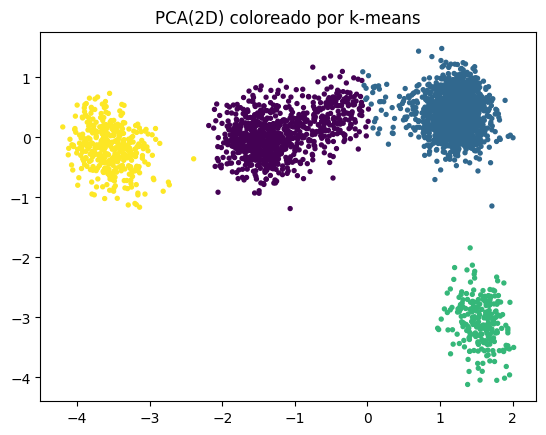

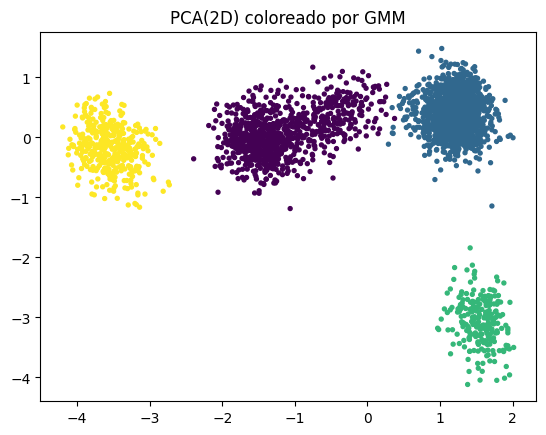

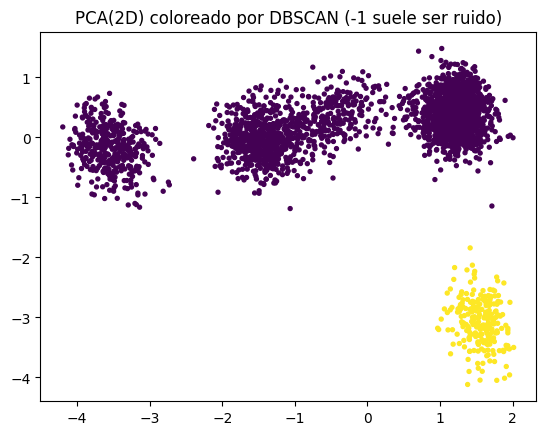

In [11]:
pca = PCA(n_components=2, random_state=0)
Z = pca.fit_transform(Xz)

plt.figure()
plt.scatter(Z[:,0], Z[:,1], s=8, c=df["km"])
plt.title("PCA(2D) coloreado por k-means")
plt.show()

plt.figure()
plt.scatter(Z[:,0], Z[:,1], s=8, c=df["gmm"])
plt.title("PCA(2D) coloreado por GMM")
plt.show()

plt.figure()
plt.scatter(Z[:,0], Z[:,1], s=8, c=df["dbscan"])
plt.title("PCA(2D) coloreado por DBSCAN (-1 suele ser ruido)")
plt.show()


#  Deriva temporal: ¿cambian los lanzamientos con el tiempo?

Dos formas simples de enseñar deriva:

Cambios en centroides (velocidad/spin/movimiento).

Cambios en la mezcla de tipos de lanzamiento.

## Señal de deriva “naive”: media móvil de velocidad

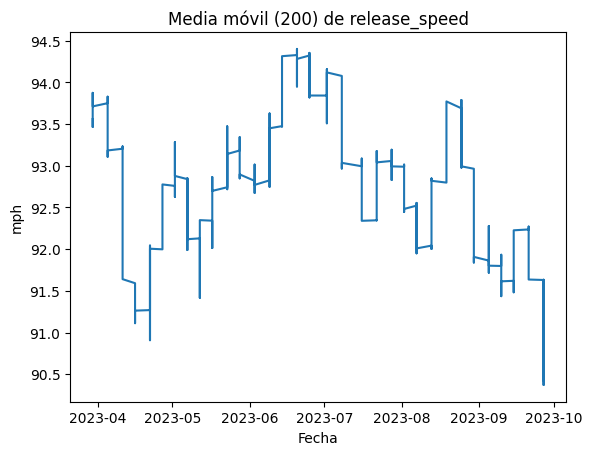

In [12]:
df["release_speed_ma"] = df["release_speed"].rolling(200, min_periods=50).mean()

plt.figure()
plt.plot(df["game_date"], df["release_speed_ma"])
plt.title("Media móvil de release_speed")
plt.xlabel("Fecha")
plt.ylabel("mph")
plt.show()


## Mezcla de pitch_type por bloques temporales

In [13]:
# Partimos temporada en 2 mitades
mid = df["game_date"].quantile(0.5)
df["half"] = np.where(df["game_date"] <= mid, "H1", "H2")

mix = (
    df.groupby(["half", "pitch_type"])
      .size()
      .groupby(level=0)
      .apply(lambda s: s / s.sum())
      .unstack(fill_value=0)
)
mix


,pitch_type,CH,FC,FF,KC,SI,SL
half,half,,,,,,
H1,H1,0.074955,0.0232,0.563950,0.119572,0.000000,0.218322
H2,H2,0.066875,0.1200,0.493125,0.121875,0.000625,0.197500


# Comparativa batch vs ventanas vs streaming

Si el proceso cambia, un modelo “entrenado una vez” puede quedarse obsoleto.

## Batch “entrenar una vez” y congelar

In [15]:
h1 = df["half"] == "H1"
h2 = df["half"] == "H2"

km_h1 = KMeans(n_clusters=k, n_init="auto", random_state=0)
lab_h1 = km_h1.fit_predict(Xz[h1])

# Etiquetas predichas en H2 usando centroides de H1
lab_h2_pred = km_h1.predict(Xz[h2])

# Para comparar "clustering de H2 entrenando en H2" vs "clustering H2 con modelo viejo"
km_h2 = KMeans(n_clusters=k, n_init="auto", random_state=0)
lab_h2_fit = km_h2.fit_predict(Xz[h2])

ari = adjusted_rand_score(lab_h2_fit, lab_h2_pred)
print("ARI(H2-fit vs H2-pred con centroides H1):", ari)


ARI(H2-fit vs H2-pred con centroides H1): 0.9869682749123118


Interpretación:

ARI alto → estructura estable.

ARI bajo → posible deriva (o clústeres no comparables por permutación / inestabilidad, útil para debatir).

## Ventanas: re-entrenar periódicamente (sliding/bloques)
Aquí hacemos “tumbling”: cada W lanzamientos, re-entrenamos k-means solo con esa ventana y guardamos centroides.
La idea es que el modelo se adapta si hay deriva.

In [16]:
W = 500  # tamaño de ventana en nº de lanzamientos
centroids = []
dates = []

for start in range(0, len(df), W):
    end = min(start + W, len(df))
    Xw = Xz[start:end]
    if len(Xw) < k:
        break

    km_w = KMeans(n_clusters=k, n_init="auto", random_state=0)
    km_w.fit(Xw)

    centroids.append(km_w.cluster_centers_)
    dates.append(df.loc[end-1, "game_date"])

centroids = np.array(centroids)  # (n_windows, k, d)
print("n_windows:", centroids.shape[0])


n_windows: 7


Para visualizar “deriva de centroides” de forma simple, miramos solo la componente release_speed (feature 0):

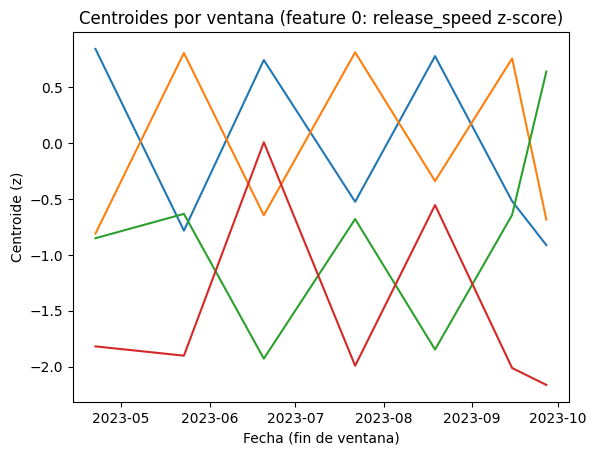

In [17]:
plt.figure()
for c in range(k):
    plt.plot(dates, centroids[:, c, 0])
plt.title("Centroides por ventana (feature 0: release_speed z-score)")
plt.xlabel("Fecha (fin de ventana)")
plt.ylabel("Centroide (z)")
plt.show()


## Streaming incremental: MiniBatchKMeans (online por micro-lotes)

MiniBatchKMeans actualiza centroides con partial_fit. Es una buena “puerta de entrada” al streaming.

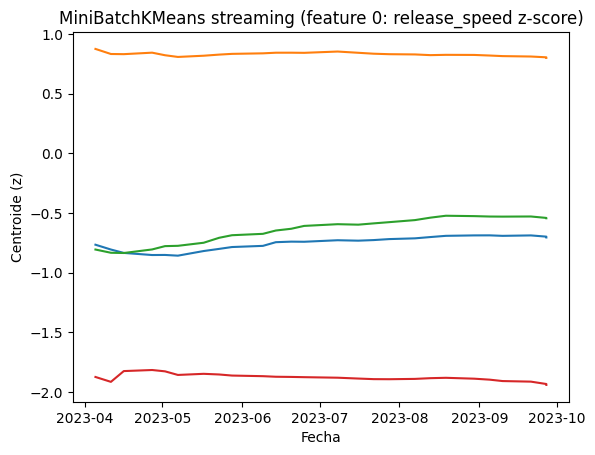

In [18]:
mbk = MiniBatchKMeans(n_clusters=k, random_state=0, batch_size=128)

centroids_stream = []
dates_stream = []

B = 128  # tamaño del micro-lote
for start in range(0, len(df), B):
    end = min(start + B, len(df))
    Xb = Xz[start:end]
    if len(Xb) < k:
        break

    mbk.partial_fit(Xb)

    centroids_stream.append(mbk.cluster_centers_.copy())
    dates_stream.append(df.loc[end-1, "game_date"])

centroids_stream = np.array(centroids_stream)

plt.figure()
for c in range(k):
    plt.plot(dates_stream, centroids_stream[:, c, 0])
plt.title("MiniBatchKMeans streaming (feature 0: release_speed z-score)")
plt.xlabel("Fecha")
plt.ylabel("Centroide (z)")
plt.show()


Qué comparar con ventanas:

Ventanas: cambios “a saltos” (reentrenas).

MiniBatch: cambios más suaves y continuos.

## Streaming por densidad (microclústeres): DenStream (river)

DenStream mantiene microclústeres (potenciales y de outliers) y usa decaimiento para olvidar.

Este bloque es para mostrar la idea (microclústeres) y qué se inspecciona: cuántos prototipos hay y cómo cambian.

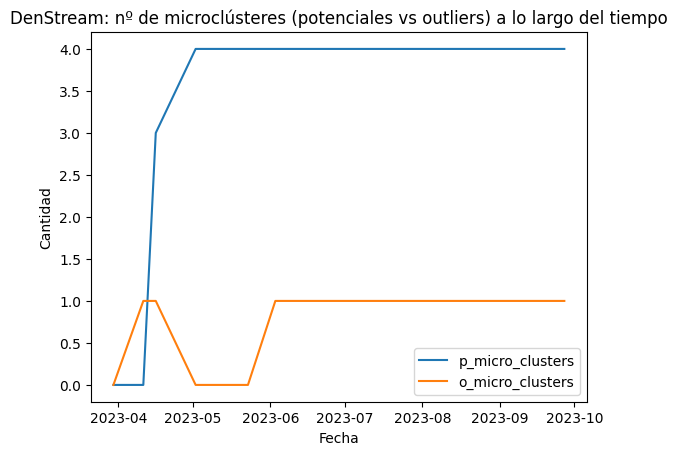

In [24]:
den = cluster.DenStream(
    decaying_factor=0.01,
    beta=0.2,
    mu=6.0,
    epsilon=0.5,
    n_samples_init=200,
    stream_speed=100
)
# River trabaja con diccionarios {feature: value}
cols = features
n_p = []
n_o = []
dates_ds = []

for i in range(len(df)):
    x = {c: float(df.loc[i, c]) for c in cols}
    # OJO: DenStream asume un stream en la escala original; si quieres, usa Xz y renombra keys.
    den.learn_one(x)

    # Contadores (según versión, estos atributos pueden existir)
    p = getattr(den, "p_micro_clusters", None)
    o = getattr(den, "o_micro_clusters", None)

    if (i % 200 == 0) and (p is not None) and (o is not None):
        n_p.append(len(p))
        n_o.append(len(o))
        dates_ds.append(df.loc[i, "game_date"])

plt.figure()
plt.plot(dates_ds, n_p, label="p_micro_clusters")
plt.plot(dates_ds, n_o, label="o_micro_clusters")
plt.title("DenStream: nº de microclústeres (potenciales vs outliers) a lo largo del tiempo")
plt.xlabel("Fecha")
plt.ylabel("Cantidad")
plt.legend()
plt.show()


Lectura docente rápida:

Si aparecen más microclústeres outlier y luego “se estabilizan”, puede indicar fases con comportamiento nuevo/ruidoso.

Si el número de microclústeres potenciales cambia, puede reflejar que el “arsenal” o las características del pitcher cambian.